# Operator Canonical Wrap-Up

`results/paper_rerun_canonical/operator` 기준으로 operator-learning 결과를 따로 정리합니다.
이번 notebook은 `Darcy`, `FNO + DeepONet`, `independent / dml / ssml` 비교에 집중합니다.


## Setup


In [1]:
from pathlib import Path
import sys

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "notebook").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root.")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
NOTEBOOK_ROOT = REPO_ROOT / "notebook" / "2026-03-18_wrapup"
FINAL_WRAPUP_ROOT = REPO_ROOT / "notebook" / "FINAL_WRAPUP"
for path in (REPO_ROOT, NOTEBOOK_ROOT, FINAL_WRAPUP_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from _shared.io import load_curve_file, load_run_tree
from _shared.plotting import apply_report_style, pretty_dataset, pretty_method, pretty_model, METHOD_COLORS

apply_report_style()
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

RESULT_ROOT = REPO_ROOT / "results" / "paper_rerun_canonical" / "operator"
FIG_ROOT = NOTEBOOK_ROOT / "figures" / "operator"
TABLE_ROOT = NOTEBOOK_ROOT / "tables" / "operator"
FIG_ROOT.mkdir(parents=True, exist_ok=True)
TABLE_ROOT.mkdir(parents=True, exist_ok=True)

METHOD_SEQUENCE = ["independent", "dml", "ssml"]
MODEL_SEQUENCE = ["fno", "deeponet"]
EXPECTED_SUMMARIES = 12

def save_fig(fig, name: str, dpi: int = 180) -> Path:
    out_path = FIG_ROOT / f"{name}.png"
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    return out_path

def save_df(df: pd.DataFrame, name: str) -> Path:
    out_path = TABLE_ROOT / f"{name}.csv"
    df.to_csv(out_path, index=False)
    return out_path

NOTEBOOK_ROOT


PosixPath('/home/namkyeong/ssmo/notebook/2026-03-18_wrapup')

In [2]:
def load_operator_summaries(result_root: Path) -> pd.DataFrame:
    summary_df = load_run_tree(result_root)
    summary_df = summary_df.loc[summary_df["task"] == "operator"].copy()
    if summary_df.empty:
        raise FileNotFoundError(f"No operator summaries found under {result_root}")
    summary_df["curve_path"] = summary_df["curve_path"].fillna("")
    summary_df["summary_path"] = summary_df["summary_path"].fillna("")
    summary_df["seed"] = summary_df["seed"].astype(int)
    summary_df["pair_type"] = summary_df["pair_type"].fillna("single")
    return summary_df.sort_values(["dataset", "method", "model", "seed"]).reset_index(drop=True)


def explode_model_results(summary_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for record in summary_df.to_dict("records"):
        curve_path = record.get("curve_path") or ""
        common = {
            "task": record.get("task"),
            "dataset": record.get("dataset"),
            "method": record.get("method"),
            "seed": int(record.get("seed", 0)),
            "curve_path": curve_path,
            "summary_path": record.get("summary_path"),
            "pair_tag": record.get("pair_tag"),
            "pair_type": record.get("pair_type"),
            "is_joint_training": bool(record.get("is_joint_training", False)),
        }

        rows.append(
            {
                **common,
                "model": record.get("model1") or record.get("model"),
                "peer_model": record.get("model2") or record.get("peer_model"),
                "role": "single" if record.get("pair_type") == "single" else "primary",
                "best_val_mse": float(record.get("best_metric1", record.get("best_metric"))),
                "final_val_mse": float(record.get("final_metric1", record.get("final_metric"))),
                "final_val_mae": float(record.get("final_val_mae1", record.get("final_val_mae", np.nan))),
                "curve_key": "val_mse1" if record.get("pair_type") != "single" else "val_mse",
            }
        )

        if record.get("pair_type") != "single" and record.get("model2"):
            rows.append(
                {
                    **common,
                    "model": record.get("model2"),
                    "peer_model": record.get("model1") or record.get("model"),
                    "role": "peer",
                    "best_val_mse": float(record.get("best_metric2")),
                    "final_val_mse": float(record.get("final_metric2")),
                    "final_val_mae": float(record.get("final_val_mae2", np.nan)),
                    "curve_key": "val_mse2",
                }
            )
    return pd.DataFrame(rows)


def aggregate_metrics(model_df: pd.DataFrame) -> pd.DataFrame:
    grouped = (
        model_df.groupby(["dataset", "model", "method"], as_index=False)
        .agg(
            runs=("seed", "count"),
            mean_best_val_mse=("best_val_mse", "mean"),
            std_best_val_mse=("best_val_mse", "std"),
            mean_final_val_mse=("final_val_mse", "mean"),
            std_final_val_mse=("final_val_mse", "std"),
            mean_final_val_mae=("final_val_mae", "mean"),
            std_final_val_mae=("final_val_mae", "std"),
        )
    )
    grouped["std_best_val_mse"] = grouped["std_best_val_mse"].fillna(0.0)
    grouped["std_final_val_mse"] = grouped["std_final_val_mse"].fillna(0.0)
    grouped["std_final_val_mae"] = grouped["std_final_val_mae"].fillna(0.0)
    grouped["dataset_label"] = grouped["dataset"].map(pretty_dataset)
    grouped["model_label"] = grouped["model"].map(pretty_model)
    grouped["method_label"] = grouped["method"].map(pretty_method)
    return grouped.sort_values(
        by=["dataset", "model", "method"],
        key=lambda s: s.map(
            {
                **{name: idx for idx, name in enumerate(MODEL_SEQUENCE)},
                **{name: idx for idx, name in enumerate(METHOD_SEQUENCE)},
                "darcy": 0,
            }
        ).fillna(99),
    ).reset_index(drop=True)


def format_summary_table(agg_df: pd.DataFrame) -> pd.DataFrame:
    table = agg_df.copy()
    table["best_val_mse"] = table.apply(lambda row: f"{row['mean_best_val_mse']:.6f} ± {row['std_best_val_mse']:.6f}", axis=1)
    table["final_val_mse"] = table.apply(lambda row: f"{row['mean_final_val_mse']:.6f} ± {row['std_final_val_mse']:.6f}", axis=1)
    table["final_val_mae"] = table.apply(lambda row: f"{row['mean_final_val_mae']:.6f} ± {row['std_final_val_mae']:.6f}", axis=1)
    return table[["dataset_label", "model_label", "method_label", "runs", "best_val_mse", "final_val_mse", "final_val_mae"]]


def barplot_metric(agg_df: pd.DataFrame, value_col: str, error_col: str, title: str, ylabel: str):
    models = MODEL_SEQUENCE
    methods = METHOD_SEQUENCE
    x = np.arange(len(models))
    width = 0.22
    fig, ax = plt.subplots(figsize=(9.0, 4.8))
    for idx, method in enumerate(methods):
        offsets = x + (idx - 1) * width
        vals = []
        errs = []
        for model in models:
            row = agg_df[(agg_df["model"] == model) & (agg_df["method"] == method)]
            vals.append(float(row.iloc[0][value_col]) if not row.empty else np.nan)
            errs.append(float(row.iloc[0][error_col]) if not row.empty else 0.0)
        ax.bar(offsets, vals, width=width, label=pretty_method(method), color=METHOD_COLORS[method], alpha=0.95)
        ax.errorbar(offsets, vals, yerr=errs, fmt="none", ecolor="#2e3440", capsize=3, linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels([pretty_model(model) for model in models])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(ncol=3, loc="upper right")
    fig.tight_layout()
    return fig


def seed_spread_plot(model_df: pd.DataFrame):
    fig, axes = plt.subplots(1, len(MODEL_SEQUENCE), figsize=(11.0, 4.2), sharey=True)
    if len(MODEL_SEQUENCE) == 1:
        axes = [axes]
    for ax, model in zip(axes, MODEL_SEQUENCE):
        subset = model_df[model_df["model"] == model].copy()
        for idx, method in enumerate(METHOD_SEQUENCE):
            rows = subset[subset["method"] == method].sort_values("seed")
            x = np.full(len(rows), idx, dtype=float) + np.linspace(-0.08, 0.08, len(rows))
            ax.scatter(x, rows["best_val_mse"], s=45, color=METHOD_COLORS[method], label=pretty_method(method) if model == MODEL_SEQUENCE[0] else None)
        ax.set_xticks(range(len(METHOD_SEQUENCE)))
        ax.set_xticklabels([pretty_method(method) for method in METHOD_SEQUENCE], rotation=0)
        ax.set_title(pretty_model(model))
        ax.set_ylabel("Best Validation MSE")
        ax.grid(alpha=0.25)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.02))
    fig.suptitle("Seed-Level Spread of Best Validation MSE", y=1.08)
    fig.tight_layout()
    return fig


def representative_primary_curve(model_df: pd.DataFrame, focus_model: str = "fno"):
    fig, ax = plt.subplots(figsize=(9.0, 4.8))
    for method in METHOD_SEQUENCE:
        subset = model_df[(model_df["model"] == focus_model) & (model_df["method"] == method)]
        if subset.empty:
            continue
        picked = subset.sort_values("best_val_mse", ascending=True).iloc[0]
        curves = load_curve_file(picked["curve_path"])
        curve = np.asarray(curves[picked["curve_key"]], dtype=float).reshape(-1)
        ax.plot(np.arange(1, len(curve) + 1), curve, linewidth=2.0, color=METHOD_COLORS[method], label=f"{pretty_method(method)} (seed {int(picked['seed'])})")
    ax.set_title(f"Representative Validation Curves for {pretty_model(focus_model)}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation MSE")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig


def best_joint_pair_curve(summary_df: pd.DataFrame, method: str = "ssml"):
    subset = summary_df[(summary_df["method"] == method) & (summary_df["pair_type"] == "heterogeneous")].copy()
    if subset.empty:
        raise ValueError(f"No joint runs found for method={method}")
    picked = subset.sort_values("best_metric1", ascending=True).iloc[0]
    curves = load_curve_file(picked["curve_path"])
    curve1 = np.asarray(curves["val_mse1"], dtype=float).reshape(-1)
    curve2 = np.asarray(curves["val_mse2"], dtype=float).reshape(-1)
    fig, ax = plt.subplots(figsize=(9.0, 4.8))
    epochs = np.arange(1, len(curve1) + 1)
    ax.plot(epochs, curve1, label=f"{pretty_model(picked['model1'])} ({pretty_method(method)})", color="#5e81ac", linewidth=2.0)
    ax.plot(epochs, curve2, label=f"{pretty_model(picked['model2'])} ({pretty_method(method)})", color="#d08770", linewidth=2.0)
    ax.set_title(f"Best Joint Pair Curve | {pretty_dataset(picked['dataset'])} | seed {int(picked['seed'])}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation MSE")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig, picked


## Load


In [3]:
summary_df = load_operator_summaries(RESULT_ROOT)
if len(summary_df) != EXPECTED_SUMMARIES:
    display(Markdown(f"**Warning:** expected {EXPECTED_SUMMARIES} summaries, found {len(summary_df)}"))
else:
    display(Markdown(f"**Loaded:** {len(summary_df)} operator summaries from `{RESULT_ROOT}`"))

raw_path = save_df(summary_df, "operator_summary_runs")
summary_df[["dataset", "method", "model", "peer_model", "pair_type", "seed", "best_metric1", "best_metric2", "final_metric1", "final_metric2"]]


**Loaded:** 12 operator summaries from `/home/namkyeong/ssmo/results/paper_rerun_canonical/operator`

,dataset,method,model,peer_model,pair_type,seed,best_metric1,best_metric2,final_metric1,final_metric2
0,darcy,dml,fno,deeponet,heterogeneous,0,0.005521,0.012803,0.005869,0.015029
1,darcy,dml,fno,deeponet,heterogeneous,1,0.004074,0.012479,0.004411,0.012479
2,darcy,dml,fno,deeponet,heterogeneous,2,0.004611,0.013120,0.004784,0.013297
3,darcy,independent,deeponet,None,single,0,0.012410,NaN,0.012410,NaN
4,darcy,independent,deeponet,None,single,1,0.012191,NaN,0.012191,NaN
5,darcy,independent,deeponet,None,single,2,0.013087,NaN,0.014588,NaN
6,darcy,independent,fno,None,single,0,0.003344,NaN,0.003403,NaN
7,darcy,independent,fno,None,single,1,0.002316,NaN,0.002322,NaN
8,darcy,independent,fno,None,single,2,0.002968,NaN,0.003070,NaN
9,darcy,ssml,fno,deeponet,heterogeneous,0,0.002878,0.011782,0.003066,0.013864


## Normalize


In [4]:
model_df = explode_model_results(summary_df)
agg_df = aggregate_metrics(model_df)

model_results_path = save_df(model_df, "operator_model_results")
agg_path = save_df(agg_df, "operator_method_summary")

display(Markdown(f"Saved raw runs to `{raw_path}`"))
display(Markdown(f"Saved exploded model rows to `{model_results_path}`"))
display(Markdown(f"Saved aggregated summary to `{agg_path}`"))
model_df.head()


Saved raw runs to `/home/namkyeong/ssmo/notebook/2026-03-18_wrapup/tables/operator/operator_summary_runs.csv`

Saved exploded model rows to `/home/namkyeong/ssmo/notebook/2026-03-18_wrapup/tables/operator/operator_model_results.csv`

Saved aggregated summary to `/home/namkyeong/ssmo/notebook/2026-03-18_wrapup/tables/operator/operator_method_summary.csv`

,task,dataset,method,seed,curve_path,summary_path,pair_tag,pair_type,is_joint_training,model,peer_model,role,best_val_mse,final_val_mse,final_val_mae,curve_key
0,operator,darcy,dml,0,/home/namkyeong/ssmo/results/paper_rerun_canon...,/home/namkyeong/ssmo/results/paper_rerun_canon...,fno__deeponet,heterogeneous,True,fno,deeponet,primary,0.005521,0.005869,0.049440,val_mse1
1,operator,darcy,dml,0,/home/namkyeong/ssmo/results/paper_rerun_canon...,/home/namkyeong/ssmo/results/paper_rerun_canon...,fno__deeponet,heterogeneous,True,deeponet,fno,peer,0.012803,0.015029,0.091128,val_mse2
2,operator,darcy,dml,1,/home/namkyeong/ssmo/results/paper_rerun_canon...,/home/namkyeong/ssmo/results/paper_rerun_canon...,fno__deeponet,heterogeneous,True,fno,deeponet,primary,0.004074,0.004411,0.046217,val_mse1
3,operator,darcy,dml,1,/home/namkyeong/ssmo/results/paper_rerun_canon...,/home/namkyeong/ssmo/results/paper_rerun_canon...,fno__deeponet,heterogeneous,True,deeponet,fno,peer,0.012479,0.012479,0.082696,val_mse2
4,operator,darcy,dml,2,/home/namkyeong/ssmo/results/paper_rerun_canon...,/home/namkyeong/ssmo/results/paper_rerun_canon...,fno__deeponet,heterogeneous,True,fno,deeponet,primary,0.004611,0.004784,0.045263,val_mse1


## Summary Table


In [5]:
summary_table = format_summary_table(agg_df)
table_path = save_df(summary_table, "operator_summary_table")
display(Markdown(f"Saved formatted summary table to `{table_path}`"))
summary_table


Saved formatted summary table to `/home/namkyeong/ssmo/notebook/2026-03-18_wrapup/tables/operator/operator_summary_table.csv`

,dataset_label,model_label,method_label,runs,best_val_mse,final_val_mse,final_val_mae
0,darcy,FNO,Independent,3,0.002876 ± 0.000520,0.002932 ± 0.000554,0.031831 ± 0.001598
1,darcy,FNO,DML,3,0.004735 ± 0.000732,0.005021 ± 0.000758,0.046974 ± 0.002189
2,darcy,FNO,SSML,3,0.002457 ± 0.000441,0.002546 ± 0.000502,0.029712 ± 0.001667
3,darcy,DeepONet,Independent,3,0.012563 ± 0.000467,0.013063 ± 0.001325,0.083245 ± 0.004977
4,darcy,DeepONet,DML,3,0.012801 ± 0.000320,0.013602 ± 0.001302,0.085427 ± 0.004939
5,darcy,DeepONet,SSML,3,0.012297 ± 0.000582,0.013304 ± 0.000949,0.084979 ± 0.005404


## Main Figures


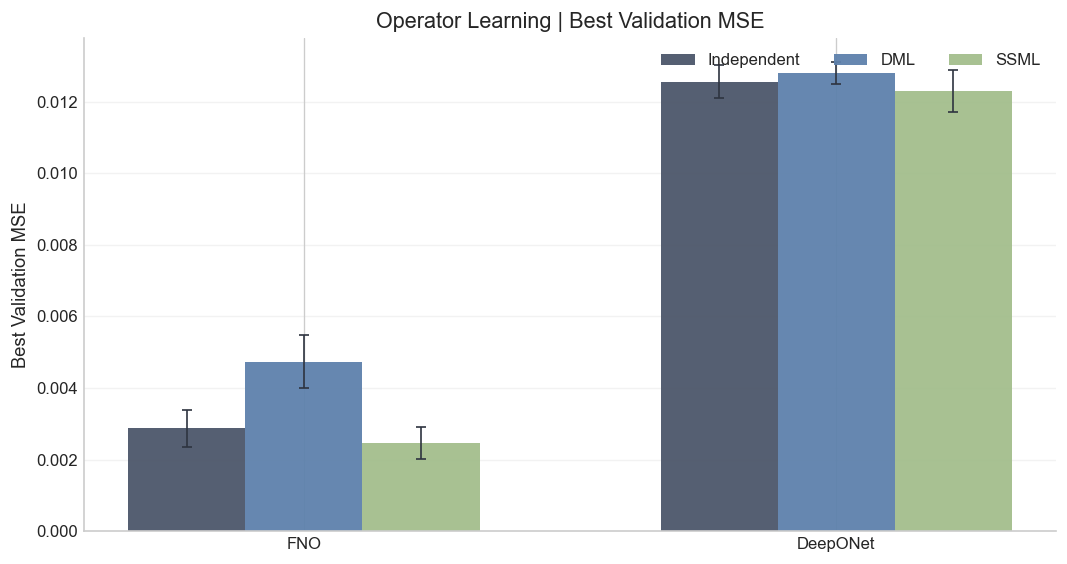

Saved: /home/namkyeong/ssmo/notebook/2026-03-18_wrapup/figures/operator/operator_best_val_mse_comparison.png


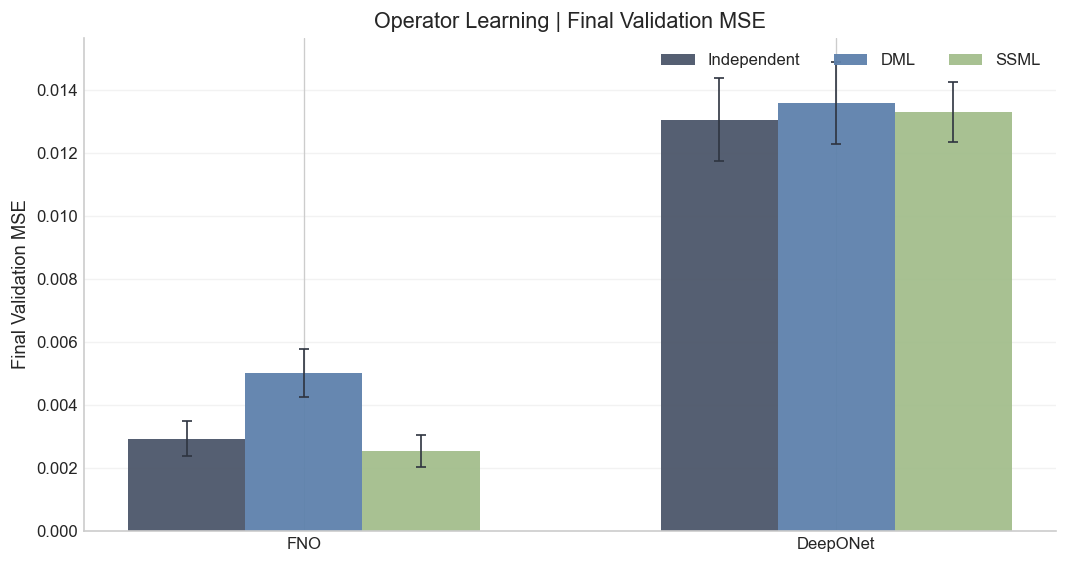

Saved: /home/namkyeong/ssmo/notebook/2026-03-18_wrapup/figures/operator/operator_final_val_mse_comparison.png


In [6]:
fig_best = barplot_metric(
    agg_df,
    value_col="mean_best_val_mse",
    error_col="std_best_val_mse",
    title="Operator Learning | Best Validation MSE",
    ylabel="Best Validation MSE",
)
best_path = save_fig(fig_best, "operator_best_val_mse_comparison")
plt.show()
print(f"Saved: {best_path}")

fig_final = barplot_metric(
    agg_df,
    value_col="mean_final_val_mse",
    error_col="std_final_val_mse",
    title="Operator Learning | Final Validation MSE",
    ylabel="Final Validation MSE",
)
final_path = save_fig(fig_final, "operator_final_val_mse_comparison")
plt.show()
print(f"Saved: {final_path}")


## Secondary Figures


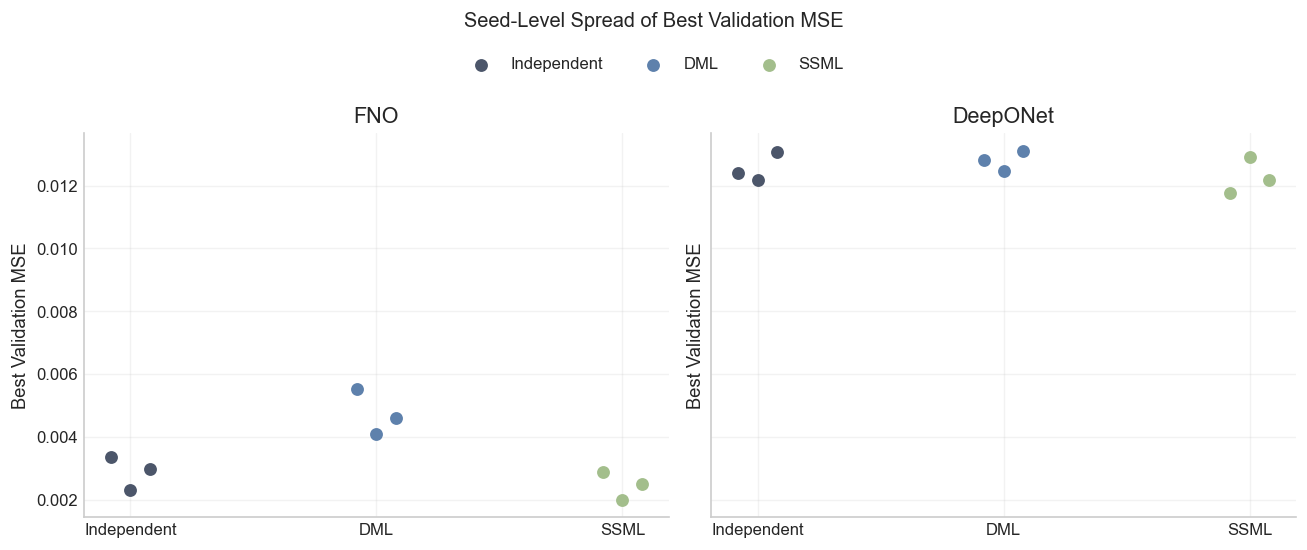

Saved: /home/namkyeong/ssmo/notebook/2026-03-18_wrapup/figures/operator/operator_seed_spread.png


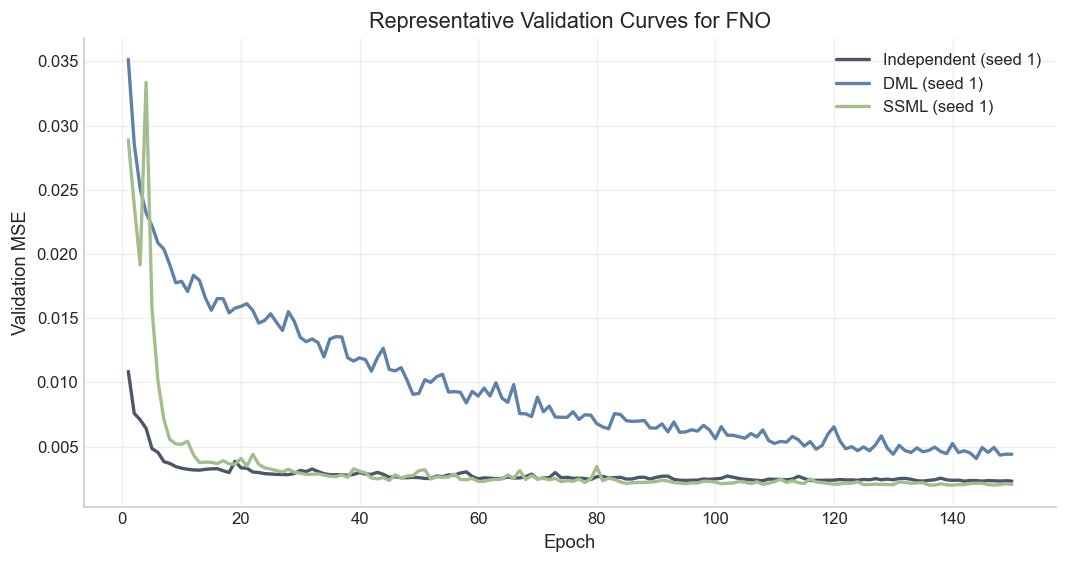

Saved: /home/namkyeong/ssmo/notebook/2026-03-18_wrapup/figures/operator/operator_fno_representative_curves.png


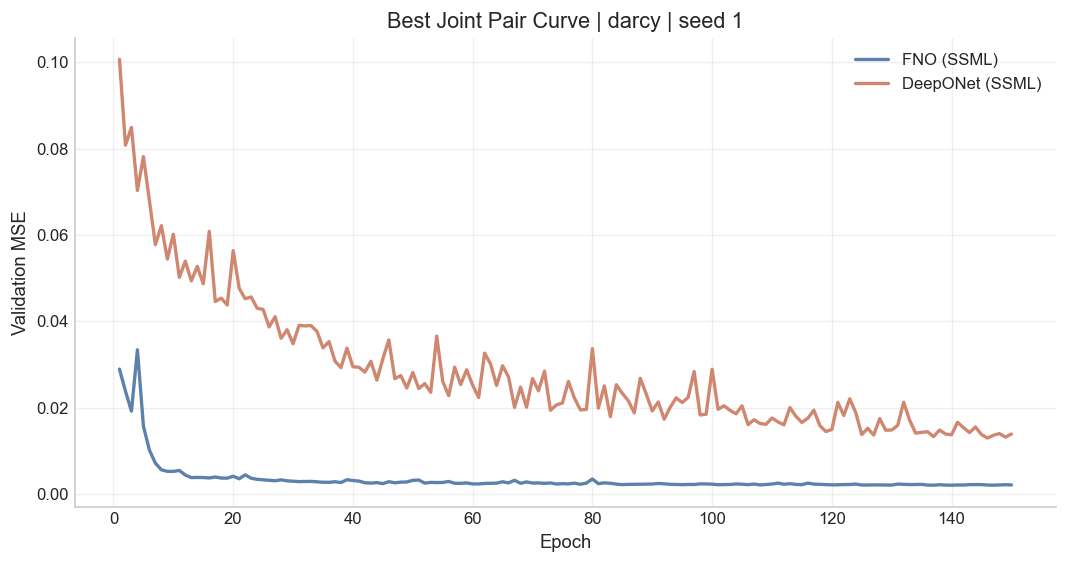

Saved: /home/namkyeong/ssmo/notebook/2026-03-18_wrapup/figures/operator/operator_best_ssml_joint_curve.png


dataset               darcy
method                 ssml
model1                  fno
model2             deeponet
seed                      1
best_metric1     0.00199827
best_metric2      0.0129277
final_metric1    0.00206516
final_metric2     0.0138404
Name: 10, dtype: object

In [7]:
fig_seed = seed_spread_plot(model_df)
seed_path = save_fig(fig_seed, "operator_seed_spread")
plt.show()
print(f"Saved: {seed_path}")

fig_curve = representative_primary_curve(model_df, focus_model="fno")
curve_path = save_fig(fig_curve, "operator_fno_representative_curves")
plt.show()
print(f"Saved: {curve_path}")

fig_joint, picked_joint = best_joint_pair_curve(summary_df, method="ssml")
joint_path = save_fig(fig_joint, "operator_best_ssml_joint_curve")
plt.show()
print(f"Saved: {joint_path}")
picked_joint[["dataset", "method", "model1", "model2", "seed", "best_metric1", "best_metric2", "final_metric1", "final_metric2"]]


## Export


In [8]:
export_manifest = pd.DataFrame(
    [
        {"kind": "table", "path": str(path)}
        for path in sorted(TABLE_ROOT.glob("*.csv"))
    ]
    + [
        {"kind": "figure", "path": str(path)}
        for path in sorted(FIG_ROOT.glob("*.png"))
    ]
)
manifest_path = save_df(export_manifest, "operator_export_manifest")
display(Markdown(f"Saved export manifest to `{manifest_path}`"))
export_manifest


Saved export manifest to `/home/namkyeong/ssmo/notebook/2026-03-18_wrapup/tables/operator/operator_export_manifest.csv`

,kind,path
0,table,/home/namkyeong/ssmo/notebook/2026-03-18_wrapu...
1,table,/home/namkyeong/ssmo/notebook/2026-03-18_wrapu...
2,table,/home/namkyeong/ssmo/notebook/2026-03-18_wrapu...
3,table,/home/namkyeong/ssmo/notebook/2026-03-18_wrapu...
4,table,/home/namkyeong/ssmo/notebook/2026-03-18_wrapu...
5,figure,/home/namkyeong/ssmo/notebook/2026-03-18_wrapu...
6,figure,/home/namkyeong/ssmo/notebook/2026-03-18_wrapu...
7,figure,/home/namkyeong/ssmo/notebook/2026-03-18_wrapu...
8,figure,/home/namkyeong/ssmo/notebook/2026-03-18_wrapu...
9,figure,/home/namkyeong/ssmo/notebook/2026-03-18_wrapu...


## Notes


In [9]:
best_rows = (
    agg_df.sort_values(["model", "mean_best_val_mse"], ascending=[True, True])
    .groupby("model", as_index=False)
    .first()[["model", "method", "mean_best_val_mse", "mean_final_val_mse"]]
)
best_rows["model"] = best_rows["model"].map(pretty_model)
best_rows["method"] = best_rows["method"].map(pretty_method)
best_rows


,model,method,mean_best_val_mse,mean_final_val_mse
0,DeepONet,SSML,0.012297,0.013304
1,FNO,SSML,0.002457,0.002546
